# NB-05: Inference Demo

**Purpose:** Test the full inference pipeline on a single video file.

**Output:** Anomaly verdict, crime type, confidence, timestamps, and ROI bounding box.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np

from src.inference import VideoAnomalyDetector
from src.roi import draw_roi, overlay_heatmap

print('Modules loaded.')

c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Can not import selective_scan_cuda_oflex. This affects speed.
Modules loaded.


c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\model\lib_mamba\csm_triton.py:11: UserWarning: Triton not installed, fall back to pytorch implements. (Error: No module named 'triton')
  warnings.warn(f"Triton not installed, fall back to pytorch implements. (Error: {e})")
c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\model\lib_mamba\csms6s.py:13: UserWarning: Can not import selective_scan_cuda_oflex. This affects speed.
  warnings.warn("Can not import selective_scan_cuda_oflex. This affects speed.")
c:\Users\sunny\OneDrive\Desktop\MobilMamba\mm\model\lib_mamba\csms6s.py:73: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_ty

In [2]:
# ─── Initialise Detector ──────────────────────────────
detector = VideoAnomalyDetector(
    model_path='../checkpoints/best_model.pth',
    config_path='../configs/crime_classes.yaml',
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
print('Detector ready.')

[Detector] Model loaded from ../checkpoints/best_model.pth on cuda
Detector ready.


In [3]:
# ─── Analyse a Video ──────────────────────────────────
# UPDATE THIS PATH to point to your test video
TEST_VIDEO = '../data/raw/Robbery/Robbery140_x264.mp4'  # example

results = detector.analyze_video(TEST_VIDEO)

print(f'\n{"="*60}')
print(f'  Video: {results["video"]}')
print(f'  Frames processed: {results["frame_count"]}')
print(f'  Events detected:  {len(results["events"])}')
print(f'{"="*60}')

for i, event in enumerate(results['events']):
    print(f'\n  Event {i+1}:')
    print(f'    Time:       [{event["start_time"]:.2f}s — {event["end_time"]:.2f}s]')
    print(f'    Crime:      {event["crime_type"]}')
    print(f'    Confidence: {event["confidence"]*100:.1f}%')
    print(f'    ROI bbox:   {event["roi_bbox"]}')

[Detector] Analysing: ../data/raw/Robbery/Robbery140_x264.mp4
  FPS: 30.0  |  Total frames: 1068  |  Sample rate: 1/10
[Detector] Done. 1 event(s) detected in Robbery140_x264.

  Video: ../data/raw/Robbery/Robbery140_x264.mp4
  Frames processed: 1068
  Events detected:  1

  Event 1:
    Time:       [0.33s — 35.60s]
    Crime:      Robbery
    Confidence: 79.2%
    ROI bbox:   {'x': 0, 'y': 93, 'w': 196, 'h': 147}


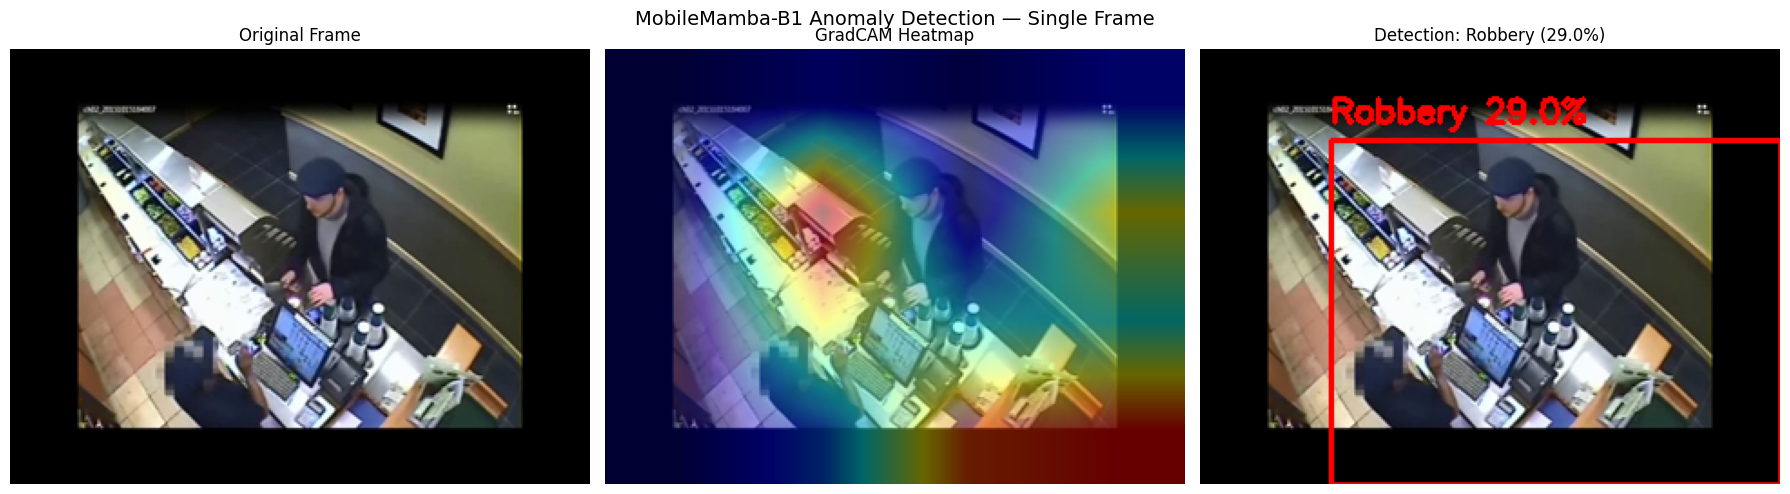

: 

In [ ]:
# ─── Visualise a Single Frame with GradCAM ────────────
cap = cv2.VideoCapture(TEST_VIDEO)
# Jump to middle of video
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
ret, frame = cap.read()
cap.release()

if ret:
    # Run prediction + GradCAM
    tensor = detector.preprocess(frame)
    cam, class_idx, probs = detector.model.get_gradcam(tensor)
    crime_type = detector.model.get_class_name(class_idx)
    confidence = probs[class_idx].item()

    # Get ROI
    from src.roi import extract_roi_bbox
    bbox = extract_roi_bbox(frame, cam, threshold=0.4)

    # Draw
    frame_annotated = draw_roi(frame, bbox, crime_type, confidence)
    frame_heatmap = overlay_heatmap(frame, cam, alpha=0.4)

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Frame')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(frame_heatmap, cv2.COLOR_BGR2RGB))
    axes[1].set_title('GradCAM Heatmap')
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(frame_annotated, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'Detection: {crime_type} ({confidence*100:.1f}%)')
    axes[2].axis('off')

    plt.suptitle('MobileMamba-B1 Anomaly Detection — Single Frame', fontsize=14)
    plt.tight_layout()
    plt.savefig('../outputs/logs/inference_demo.png', dpi=150)
    plt.show()
else:
    print('Could not read frame from video.')

In [12]:
# ─── Show Saved Events ────────────────────────────────
import json
from pathlib import Path

events_dir = Path('../outputs/events')
event_files = sorted(events_dir.glob('*.json'))

print(f'\nSaved event files ({len(event_files)}):')  
for f in event_files[-5:]:  # show last 5
    with open(f) as fp:
        data = json.load(fp)
    print(f'\n  {f.name}:')
    print(f'    {json.dumps(data, indent=4)}')


Saved event files (3):

  Assault001_x264_Assault_20260328_092231.json:
    {
    "video": "Assault001_x264",
    "start_time": 0.33,
    "end_time": 82.87,
    "duration_seconds": 82.54,
    "crime_type": "Assault",
    "confidence": 0.9902,
    "roi_bbox": {
        "x": 0,
        "y": 59,
        "w": 320,
        "h": 143
    },
    "frame_sample_rate": 10,
    "model": "MobileMamba-B1-AnomalyV1"
}

  Assault052_x264_Abuse_20260328_092255.json:
    {
    "video": "Assault052_x264",
    "start_time": 0.33,
    "end_time": 26.3,
    "duration_seconds": 25.97,
    "crime_type": "Abuse",
    "confidence": 1.0,
    "roi_bbox": {
        "x": 87,
        "y": 45,
        "w": 233,
        "h": 142
    },
    "frame_sample_rate": 10,
    "model": "MobileMamba-B1-AnomalyV1"
}

  Robbery140_x264_Robbery_20260328_092456.json:
    {
    "video": "Robbery140_x264",
    "start_time": 0.33,
    "end_time": 35.6,
    "duration_seconds": 35.27,
    "crime_type": "Robbery",
    "confidence": 0.99